# Cartesian to Polar coordinates function Testing  

**Purpose**: Code for testing the Cartesian to Polar coordinate functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline


Import python libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pyproj import Geod
from scipy.interpolate import griddata

# Set path to access python functions
sys.path.append('/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/')

#--- Luke's Python Functions ---# 
from autocorr import compute_decor_scale, compute_autocorr

In [3]:
#--- Cartesian to polar coordinates transformation ---# 
def lonlat_to_polar_planar(lon, lat):
    
    """
    Transform (lon, lat) coordinates to (r, theta) polar coordinates relative
    to the grid center, using a planar (local tangent-plane) approximation.

    Parameters
    ----------
    lon : 2D array
        Longitude grid (degrees).
    lat : 2D array
        Latitude grid (degrees). Must have same shape as `lon`.

    Returns
    -------
    r : 2D array
        Radial distance from the grid center (km).
    theta : 2D array
        Polar angle (degrees), measured clockwise from north.
    """

    # Import library
    import numpy as np

    # --- Constants --- #
    R_earth = 6371.0  # Earth's mean radius [km]

    # --- Compute grid center --- #
    lon0 = np.mean(lon)
    lat0 = np.mean(lat)

    # --- Convert degrees to kilometers --- #
    deg2km_lat = (np.pi / 180.0) * R_earth                # km per degree latitude
    deg2km_lon = deg2km_lat * np.cos(np.deg2rad(lat0))    # km per degree longitude (adjust for latitude)

    # --- Compute local Cartesian offsets (dx eastward, dy northward) --- #
    dx = (lon - lon0) * deg2km_lon   # east–west distance in km
    dy = (lat - lat0) * deg2km_lat   # north–south distance in km

    # --- Polar coordinates --- #
    r = np.sqrt(dx**2 + dy**2)
    # theta: 0° = north, increases clockwise
    theta = (np.degrees(np.arctan2(dx, dy)) + 360.0) % 360.0

    return r, theta

Generate fake data and test

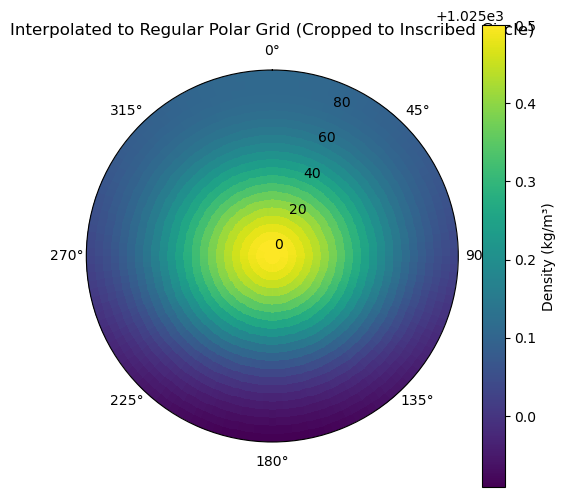

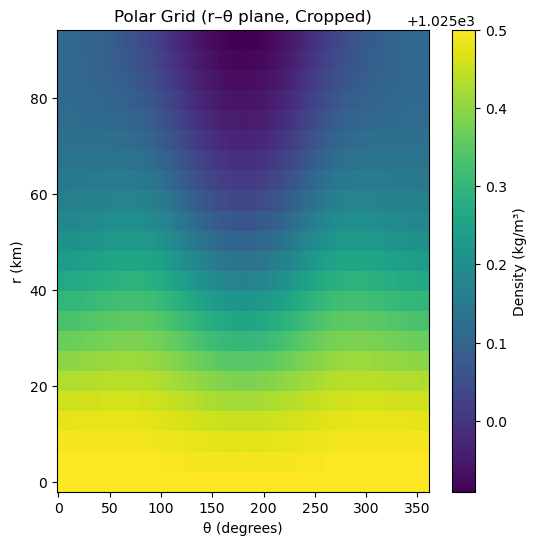

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =====================================================================
# Function: interpolate_to_polar_grid
# =====================================================================
def interpolate_to_polar_grid(lon, lat, data, lon_center, lat_center):
    """
    Interpolate a 2D field from Cartesian (lon, lat) to a regular polar grid.
    The radial (dr) and angular (dtheta) resolutions are automatically chosen
    to match the average resolution of the input Cartesian grid.
    The output is cropped to the largest inscribed circle (no NaNs outside).
    The polar angle follows the *geographic convention*: reference = North,
    increasing clockwise (θ = 0° → North, 90° → East).

    Parameters
    ----------
    lon, lat : 2D arrays
        Longitude and latitude grids (same shape).
    data : 2D array
        Data values on the (lon, lat) grid.
    lon_center, lat_center : float
        Center point for the polar coordinate transformation.

    Returns
    -------
    R : 2D array
        Radial coordinates (cropped to inscribed circle).
    THETA : 2D array
        Angular coordinates (radians, 0 = North, increasing clockwise).
    data_polar : 2D array
        Interpolated data on the polar grid.
    r_inscribed : float
        Radius of the largest inscribed circle (for reference).
    """

    # ---------------------------------------------------------
    # 1. Convert (lon, lat) grid to local Cartesian coordinates
    # ---------------------------------------------------------
    # Use a planar (flat-Earth) approximation centered on (lon_center, lat_center)
    # 1° latitude ≈ 111 km; longitude scaled by cos(latitude)
    x = (lon - lon_center) * np.cos(np.deg2rad(lat_center)) * 111.0  # km
    y = (lat - lat_center) * 111.0                                   # km

    # ---------------------------------------------------------
    # 2. Determine grid spacing and domain limits
    # ---------------------------------------------------------
    # Compute approximate resolution in x and y directions
    dx = np.nanmean(np.diff(x, axis=1))
    dy = np.nanmean(np.diff(y, axis=0))
    dr = np.mean([dx, dy])  # Representative spatial resolution (km)

    # Compute domain bounds and the radius of the largest inscribed circle
    # The inscribed circle fits fully within the rectangular grid
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    r_inscribed = min((x_max - x_min) / 2, (y_max - y_min) / 2)

    # ---------------------------------------------------------
    # 3. Define polar grid based on input resolution
    # ---------------------------------------------------------
    # (a) Define the radial coordinate array
    #     - The maximum radius is limited to the inscribed circle.
    #     - The number of bins is set so that Δr ≈ native grid spacing.
    n_r = int(np.ceil(r_inscribed / dr))
    r_bins = np.linspace(0, r_inscribed, n_r)

    # (b) Define the angular coordinate array
    #     - Choose angular spacing so the arc length at r_inscribed ≈ dr.
    #     - This keeps approximately uniform sampling density in both directions.
    dtheta = dr / max(r_inscribed, 1e-6)  # radians per bin
    n_theta = int(np.ceil(2 * np.pi / dtheta))
    theta_bins = np.linspace(0, 2 * np.pi, n_theta)

    # (c) Create the full polar grid
    R, THETA = np.meshgrid(r_bins, theta_bins)

    # ---------------------------------------------------------
    # 4. Interpolate data from (x, y) → (R, THETA)
    # ---------------------------------------------------------
    # (a) Convert from polar (R, THETA) to Cartesian (X, Y)
    #     Geographic convention: θ=0°→North, increase clockwise
    X = R * np.sin(THETA)   # East–West (x)
    Y = R * np.cos(THETA)   # North–South (y)

    # (b) Prepare the original data points for interpolation
    points = np.column_stack((x.ravel(), y.ravel()))
    values = data.ravel()

    # (c) Perform interpolation using linear method
    data_polar = griddata(points, values, (X, Y), method='linear')

    # (d) Optionally trim grid edges beyond valid interpolation region
    #     (This avoids empty radial rings due to rectangular boundary geometry)
    valid_mask = np.isfinite(data_polar)
    if np.any(valid_mask):
        # Find last radial index with valid data in any θ
        max_valid_r_index = np.max(np.where(np.any(valid_mask, axis=0)))
        R = R[:, :max_valid_r_index + 1]
        THETA = THETA[:, :max_valid_r_index + 1]
        data_polar = data_polar[:, :max_valid_r_index + 1]

    return R, THETA, data_polar, r_inscribed


# =====================================================================
# Example usage
# =====================================================================

# 1. Create synthetic (lon, lat) grid and data
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

# Example density field: Gaussian bump + linear gradient
data = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.5**2)
data += 0.1 * (lon - lon_center)

# 2–4. Interpolate to polar grid (cropped to inscribed circle)
R, THETA, data_polar, r_inscribed = interpolate_to_polar_grid(
    lon, lat, data, lon_center, lat_center
)

# 5. Plot results in polar coordinates
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
p = ax.pcolormesh(THETA, R, data_polar, cmap='viridis', shading='auto')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid (Cropped to Inscribed Circle)')
ax.grid(False)
plt.show()

# Optional Cartesian (r–θ) visualization
fig, ax = plt.subplots(figsize=(6, 6))
p = ax.pcolormesh(np.rad2deg(THETA), R, data_polar, cmap='viridis', shading='auto')
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Polar Grid (r–θ plane, Cropped)')
ax.set_xlabel('θ (degrees)')
ax.set_ylabel('r (km)')
ax.grid(False)
plt.show()


In [17]:
np.unique(np.diff(R[0,:]))

array([4.18287139, 4.18287139, 4.18287139, 4.18287139, 4.18287139])

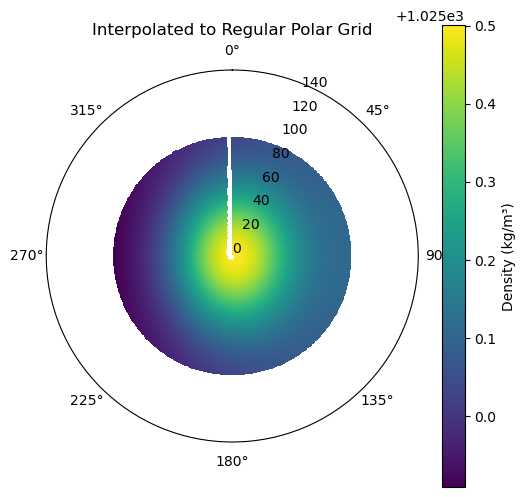

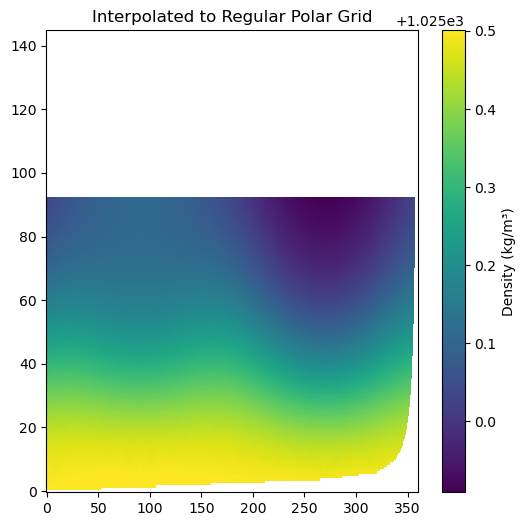

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ---------------------------------------------------------
# 1. Create synthetic (lon, lat) grid and data
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

data = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.5**2)
data += 0.1 * (lon - lon_center)

# ---------------------------------------------------------
# 2. Convert to polar coordinates
# ---------------------------------------------------------
r, theta = lonlat_to_polar_planar(lon, lat)

# ---------------------------------------------------------
# 3. Interpolate onto a regular polar grid
# ---------------------------------------------------------
# Define regular polar grid
r_bins = np.linspace(0, np.nanmax(r), 200)       # 200 radial bins
theta_bins = np.linspace(0, 360, 360)            # 1° angular bins

R, THETA = np.meshgrid(r_bins, theta_bins)
points = np.column_stack((r.ravel(), theta.ravel()))
values = data.ravel()

# Interpolate from irregular (r,theta) → regular (R,THETA)
data_polar = griddata(points, values, (R, THETA), method='linear')

# ---------------------------------------------------------
# 4. Mask outside the inscribed circle (optional)
# ---------------------------------------------------------
r_edges = np.concatenate([r[0, :], r[-1, :], r[:, 0], r[:, -1]])
r_max_valid = np.nanmin(r_edges)
data_polar[R > r_max_valid] = np.nan

# ---------------------------------------------------------
# 5. Plot clean polar field
# ---------------------------------------------------------
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

p = ax.pcolormesh(np.deg2rad(THETA), R, data_polar, cmap='viridis', shading='auto')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid')
ax.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))

p = ax.pcolormesh(THETA, R, data_polar, cmap='viridis', shading='auto')
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid')
ax.grid(False)
plt.show()

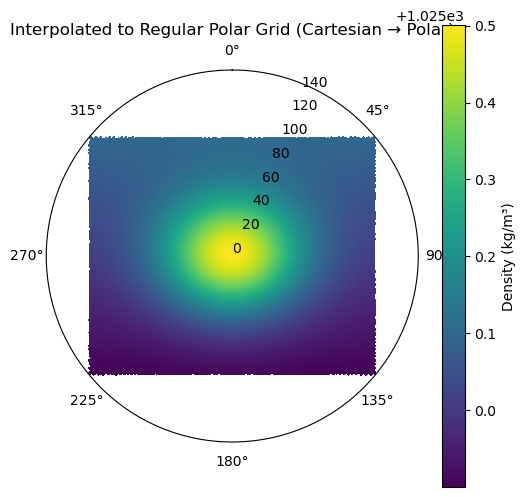

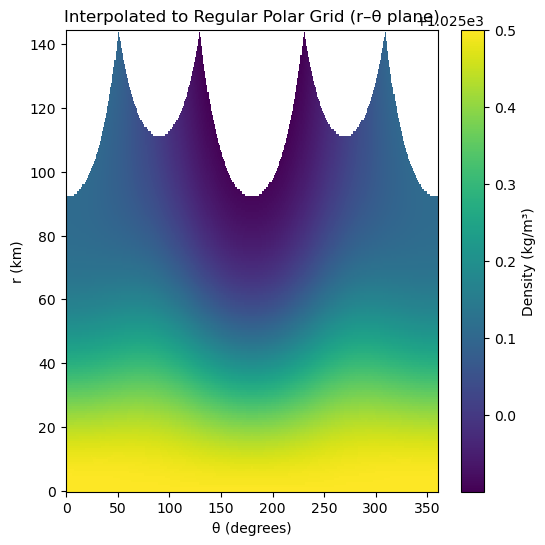

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ---------------------------------------------------------
# 1. Create synthetic (lon, lat) grid and data
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

# Example density field (smooth Gaussian bump + linear gradient)
data = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.5**2)
data += 0.1 * (lon - lon_center)

# ---------------------------------------------------------
# 2. Convert (lon, lat) grid to local Cartesian coordinates
# ---------------------------------------------------------
# Approximate planar projection centered on (lon_center, lat_center)
# Units: kilometers (1° latitude ≈ 111 km)
x = (lon - lon_center) * np.cos(np.deg2rad(lat_center)) * 111.0
y = (lat - lat_center) * 111.0

# ---------------------------------------------------------
# 3. Define regular polar grid
# ---------------------------------------------------------
r_max = np.nanmax(np.sqrt(x**2 + y**2))
r_bins = np.linspace(0, r_max, 200)               # 200 radial bins
theta_bins = np.deg2rad(np.linspace(0, 360, 360)) # 1° angular bins

R, THETA = np.meshgrid(r_bins, theta_bins)

# Convert polar grid back to Cartesian for interpolation
X = R * np.cos(THETA)
Y = R * np.sin(THETA)

# ---------------------------------------------------------
# 4. Interpolate data from (x, y) → (X, Y)
# ---------------------------------------------------------
points = np.column_stack((x.ravel(), y.ravel()))
values = data.ravel()

data_polar = griddata(points, values, (X, Y), method='linear')

# Mask points outside original data extent
data_polar[R > r_max] = np.nan

# ---------------------------------------------------------
# 5. Plot results in polar and Cartesian space
# ---------------------------------------------------------

# --- Polar plot ---
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
p = ax.pcolormesh(THETA, R, data_polar, cmap='viridis', shading='auto')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid (Cartesian → Polar)')
ax.grid(False)
plt.show()

# --- Cartesian view of polar grid ---
fig, ax = plt.subplots(figsize=(6, 6))
p = ax.pcolormesh(np.rad2deg(THETA), R, data_polar, cmap='viridis', shading='auto')
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid (r–θ plane)')
ax.set_xlabel('θ (degrees)')
ax.set_ylabel('r (km)')
ax.grid(False)
plt.show()


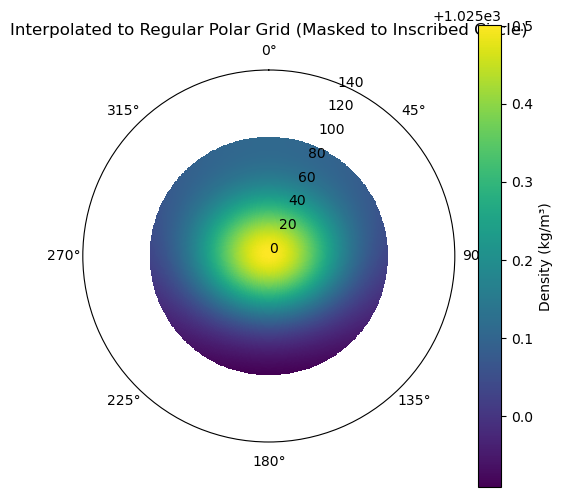

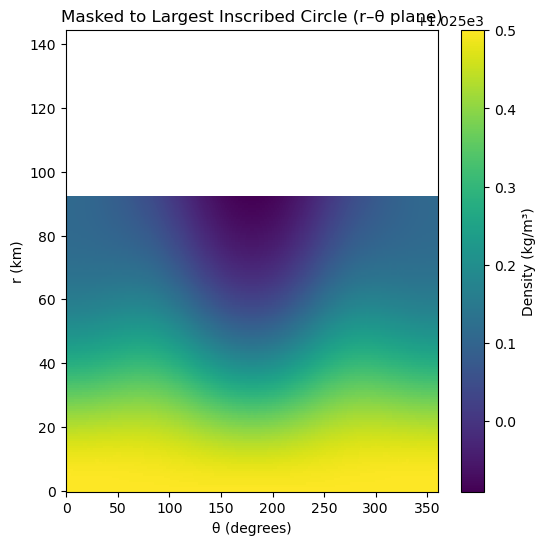

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ---------------------------------------------------------
# 1. Create synthetic (lon, lat) grid and data
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

# Example density field (smooth Gaussian bump + linear gradient)
data = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.5**2)
data += 0.1 * (lon - lon_center)

# ---------------------------------------------------------
# 2. Convert (lon, lat) grid to local Cartesian coordinates
# ---------------------------------------------------------
# Approximate planar projection centered on (lon_center, lat_center)
x = (lon - lon_center) * np.cos(np.deg2rad(lat_center)) * 111.0  # km
y = (lat - lat_center) * 111.0                                   # km

# ---------------------------------------------------------
# 3. Define regular polar grid
# ---------------------------------------------------------
r_max = np.nanmax(np.sqrt(x**2 + y**2))
r_bins = np.linspace(0, r_max, 200)
theta_bins = np.deg2rad(np.linspace(0, 360, 360))
R, THETA = np.meshgrid(r_bins, theta_bins)

# Convert polar grid back to Cartesian
X = R * np.cos(THETA)
Y = R * np.sin(THETA)

# ---------------------------------------------------------
# 4a. Interpolate data from (x, y) → (X, Y)
# ---------------------------------------------------------
points = np.column_stack((x.ravel(), y.ravel()))
values = data.ravel()
data_polar = griddata(points, values, (X, Y), method='linear')

# ---------------------------------------------------------
# 4b. Mask outside the largest inscribed circle
# ---------------------------------------------------------
x_min, x_max = np.nanmin(x), np.nanmax(x)
y_min, y_max = np.nanmin(y), np.nanmax(y)
r_inscribed = min((x_max - x_min) / 2, (y_max - y_min) / 2)

data_polar[R > r_inscribed] = np.nan

# ---------------------------------------------------------
# 5. Plot results
# ---------------------------------------------------------
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
p = ax.pcolormesh(THETA, R, data_polar, cmap='viridis', shading='auto')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid (Masked to Inscribed Circle)')
ax.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
p = ax.pcolormesh(np.rad2deg(THETA), R, data_polar, cmap='viridis', shading='auto')
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Masked to Largest Inscribed Circle (r–θ plane)')
ax.set_xlabel('θ (degrees)')
ax.set_ylabel('r (km)')
ax.grid(False)
plt.show()


# Developmental Code

Center r (km): 0.0
Corner r (km): 144.43802793004286
Center theta (deg): 0.0
Corner theta (deg): 219.66000744011077


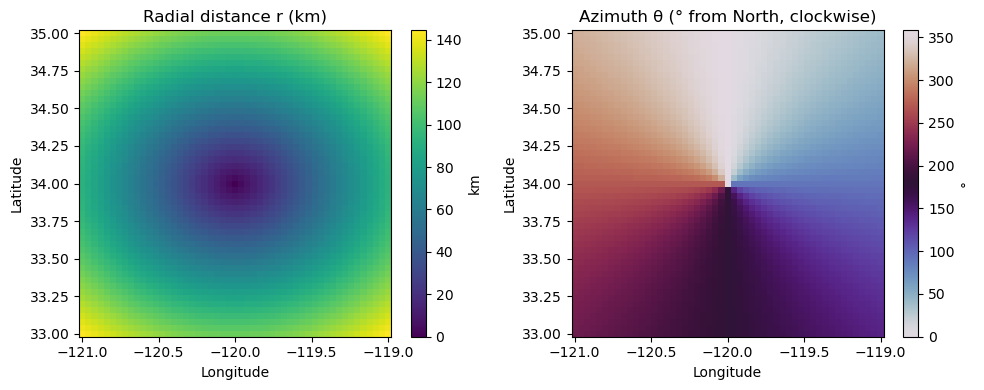

In [5]:
# ---------------------------------------------------------
# 1. Create fake lon/lat grid (e.g., 50x50 around Point Conception)
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)   # 2° span in longitude
lat = np.linspace(lat_center - 1, lat_center + 1, 51)   # 2° span in latitude
lon, lat = np.meshgrid(lon, lat)

# ---------------------------------------------------------
# 2. Use the planar polar transform
# ---------------------------------------------------------
r, theta = lonlat_to_polar_planar(lon, lat)

# ---------------------------------------------------------
# 3. Check a few sample values
# ---------------------------------------------------------
print("Center r (km):", r[25, 25])
print("Corner r (km):", r[0, 0])
print("Center theta (deg):", theta[25, 25])
print("Corner theta (deg):", theta[0, 0])

# ---------------------------------------------------------
# 4. Quick visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# r (distance)
p1 = ax[0].pcolormesh(lon, lat, r, shading='auto')
ax[0].set_title("Radial distance r (km)")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
fig.colorbar(p1, ax=ax[0], label="km")

# theta (azimuth)
p2 = ax[1].pcolormesh(lon, lat, theta, shading='auto', cmap='twilight')
ax[1].set_title("Azimuth θ (° from North, clockwise)")
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
fig.colorbar(p2, ax=ax[1], label="°")

plt.tight_layout()
plt.show()


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_29991/896969968.py:29: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p = ax.pcolormesh(theta_rad, r, density, shading='auto', cmap='viridis')


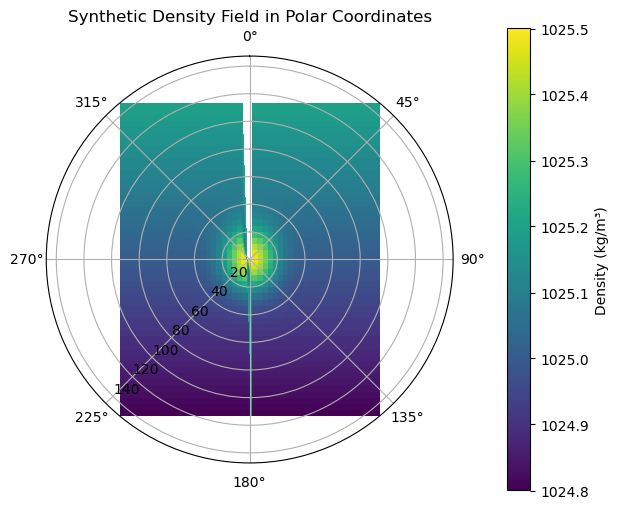

In [6]:
# ---------------------------------------------------------
# 1. Create fake (lon, lat) grid and synthetic density field
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

# Example synthetic field: a Gaussian blob + background gradient
density = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.2**2)
density += 0.2 * (lat - lat_center)  # add weak N–S gradient

# ---------------------------------------------------------
# 2. Convert to polar coordinates
# ---------------------------------------------------------

r, theta = lonlat_to_polar_planar(lon, lat)

# ---------------------------------------------------------
# 3. Plot results as polar plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='polar')

# Convert degrees to radians for plotting
theta_rad = np.deg2rad(theta)

# Plot as a filled contour (or pcolormesh)
p = ax.pcolormesh(theta_rad, r, density, shading='auto', cmap='viridis')

# Add colorbar and labels
cbar = plt.colorbar(p, ax=ax, pad=0.1)
cbar.set_label('Density (kg/m³)')
ax.set_title("Synthetic Density Field in Polar Coordinates")

# Customize radial and angular ticks
ax.set_theta_zero_location('N')  # 0° = north
ax.set_theta_direction(-1)       # clockwise
ax.set_rlabel_position(225)

plt.show()

Maximum valid radial distance: 92.18 km


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_29991/4065355136.py:39: UserWarning: Adding colorbar to a different Figure <Figure size 1200x500 with 4 Axes> than <Figure size 800x500 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(p2, ax=axes, label='Density (kg/m³)')


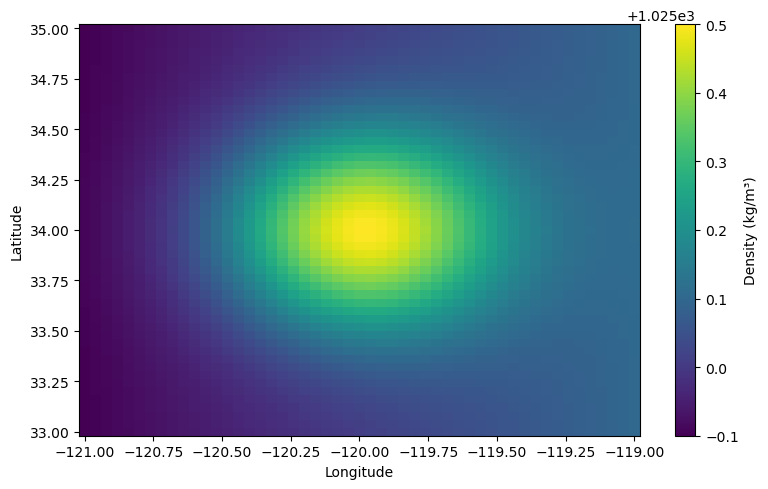

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_29991/4065355136.py:47: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p1 = axes[0].pcolormesh(np.deg2rad(theta), r, data, shading='auto', cmap='viridis')
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_29991/4065355136.py:55: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p2 = axes[1].pcolormesh(np.deg2rad(theta), r, data_trimmed, shading='auto', cmap='viridis')


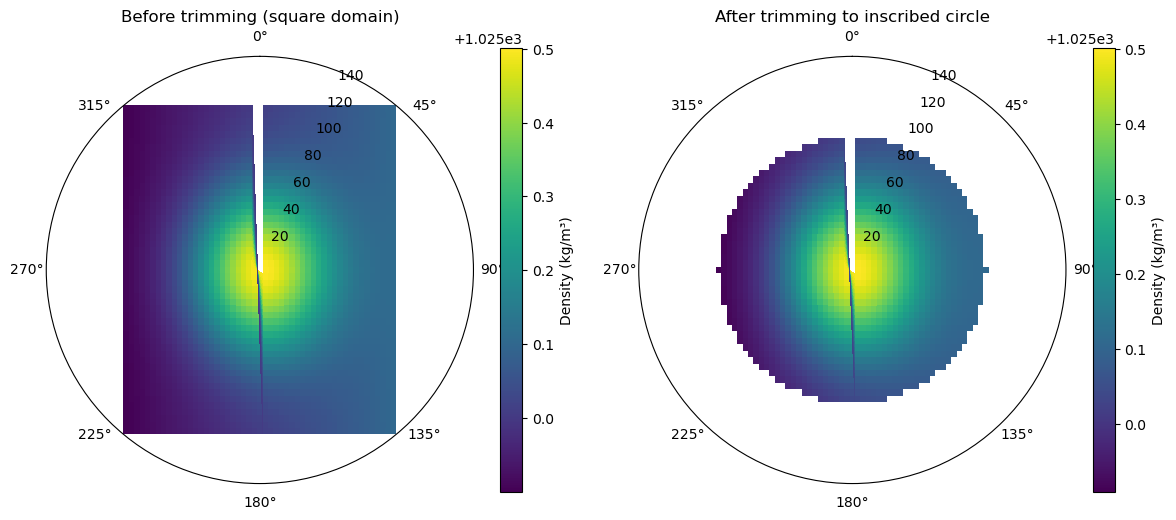

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Create synthetic (lon, lat) grid and data
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

data = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.5**2)
data += 0.1 * (lon - lon_center)

# ---------------------------------------------------------
# 2. Convert to polar coordinates
# ---------------------------------------------------------
r, theta = lonlat_to_polar_planar(lon, lat)

# ---------------------------------------------------------
# 3. Compute maximum inscribed circle (trim radius)
# ---------------------------------------------------------
# The maximum valid radius is the smallest r found along the edges of the domain
r_edges = np.concatenate([r[0, :], r[-1, :], r[:, 0], r[:, -1]])
r_max_valid = np.nanmin(r_edges)  # inscribed circle radius
print(f"Maximum valid radial distance: {r_max_valid:.2f} km")

# Mask points outside the inscribed circle
data_trimmed = np.where(r <= r_max_valid, data, np.nan)

# ---------------------------------------------------------
# 4. Plot before and after trimming
# ---------------------------------------------------------
fig, axes = plt.subplots(figsize=(8,5))

axes.pcolormesh(lon,lat,data,shading='auto',cmap='viridis')
axes.set_xlabel('Longitude')
axes.set_ylabel('Latitude')
plt.colorbar(p2, ax=axes, label='Density (kg/m³)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})

# Before trimming
p1 = axes[0].pcolormesh(np.deg2rad(theta), r, data, shading='auto', cmap='viridis')
axes[0].set_title('Before trimming (square domain)')
axes[0].set_theta_zero_location('N')
axes[0].set_theta_direction(-1)
plt.colorbar(p1, ax=axes[0], label='Density (kg/m³)')
axes[0].grid(False)

# After trimming
p2 = axes[1].pcolormesh(np.deg2rad(theta), r, data_trimmed, shading='auto', cmap='viridis')
axes[1].set_title('After trimming to inscribed circle')
axes[1].set_theta_zero_location('N')
axes[1].set_theta_direction(-1)
plt.colorbar(p2, ax=axes[1], label='Density (kg/m³)')
axes[1].grid(False)

plt.tight_layout()
plt.show()


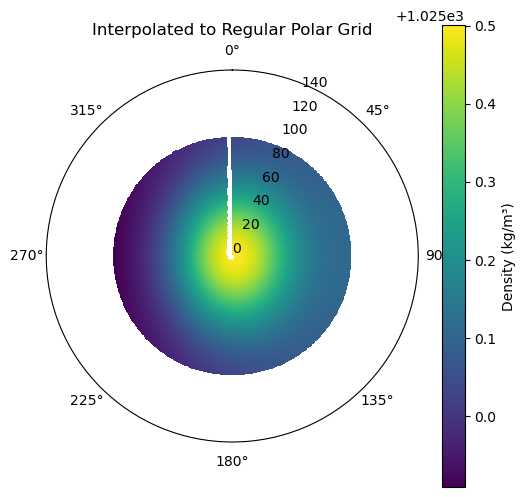

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ---------------------------------------------------------
# 1. Create synthetic (lon, lat) grid and data
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

data = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.5**2)
data += 0.1 * (lon - lon_center)

# ---------------------------------------------------------
# 2. Convert to polar coordinates
# ---------------------------------------------------------
r, theta = lonlat_to_polar_planar(lon, lat)

# ---------------------------------------------------------
# 3. Interpolate onto a regular polar grid
# ---------------------------------------------------------
# Define regular polar grid
r_bins = np.linspace(0, np.nanmax(r), 200)       # 200 radial bins
theta_bins = np.linspace(0, 360, 360)            # 1° angular bins

R, THETA = np.meshgrid(r_bins, theta_bins)
points = np.column_stack((r.ravel(), theta.ravel()))
values = data.ravel()

# Interpolate from irregular (r,theta) → regular (R,THETA)
data_polar = griddata(points, values, (R, THETA), method='linear')

# ---------------------------------------------------------
# 4. Mask outside the inscribed circle (optional)
# ---------------------------------------------------------
r_edges = np.concatenate([r[0, :], r[-1, :], r[:, 0], r[:, -1]])
r_max_valid = np.nanmin(r_edges)
data_polar[R > r_max_valid] = np.nan

# ---------------------------------------------------------
# 5. Plot clean polar field
# ---------------------------------------------------------
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

p = ax.pcolormesh(np.deg2rad(THETA), R, data_polar, cmap='viridis', shading='auto')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid')
ax.grid(False)
plt.show()


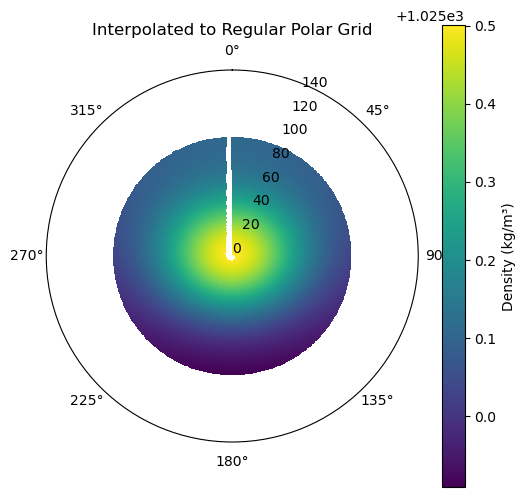

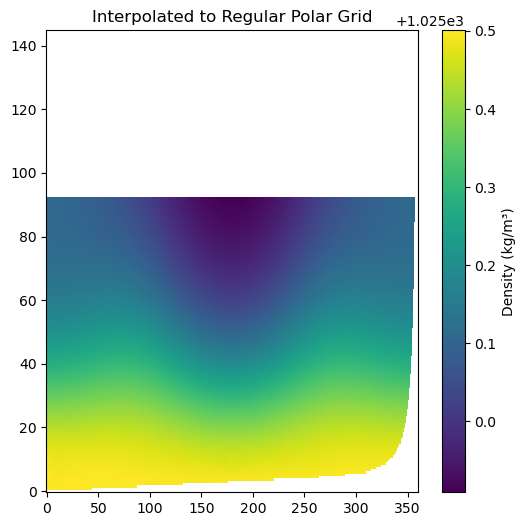

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Create synthetic (lon, lat) grid and data
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

data = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.5**2)
data += 0.1 * (lon - lon_center)

# ---------------------------------------------------------
# 2. Convert to polar coordinates (fixed angular definition)
# ---------------------------------------------------------
def lonlat_to_polar_planar(lon, lat, lon0=None, lat0=None):
    R_earth = 6371.0  # km
    if lon0 is None:
        lon0 = np.mean(lon)
    if lat0 is None:
        lat0 = np.mean(lat)

    deg2km_lat = (np.pi / 180.0) * R_earth
    deg2km_lon = deg2km_lat * np.cos(np.deg2rad(lat0))

    dx = (lon - lon0) * deg2km_lon   # east-west
    dy = (lat - lat0) * deg2km_lat   # north-south

    r = np.sqrt(dx**2 + dy**2)
    # --- key fix: arctan2(dy, dx) instead of (dx, dy) ---
    theta = (np.degrees(np.arctan2(dy, dx)) + 360.0) % 360.0
    return r, theta

r, theta = lonlat_to_polar_planar(lon, lat)

# ---------------------------------------------------------
# 3. Interpolate onto a regular polar grid
# ---------------------------------------------------------
# Define regular polar grid
r_bins = np.linspace(0, np.nanmax(r), 200)       # 200 radial bins
theta_bins = np.linspace(0, 360, 360)            # 1° angular bins

R, THETA = np.meshgrid(r_bins, theta_bins)
points = np.column_stack((r.ravel(), theta.ravel()))
values = data.ravel()

# Interpolate from irregular (r,theta) → regular (R,THETA)
data_polar = griddata(points, values, (R, THETA), method='linear')

# ---------------------------------------------------------
# 4. Mask outside the inscribed circle (optional)
# ---------------------------------------------------------
r_edges = np.concatenate([r[0, :], r[-1, :], r[:, 0], r[:, -1]])
r_max_valid = np.nanmin(r_edges)
data_polar[R > r_max_valid] = np.nan

# ---------------------------------------------------------
# 5. Plot clean polar field
# ---------------------------------------------------------
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

p = ax.pcolormesh(np.deg2rad(THETA), R, data_polar, cmap='viridis', shading='auto')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid')
ax.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))

p = ax.pcolormesh(THETA, R, data_polar, cmap='viridis', shading='auto')
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid')
ax.grid(False)
plt.show()

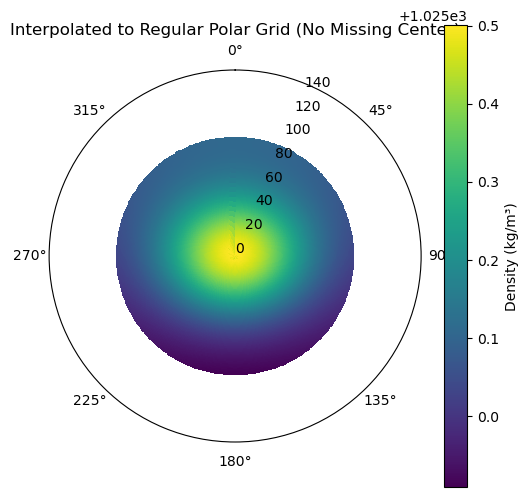

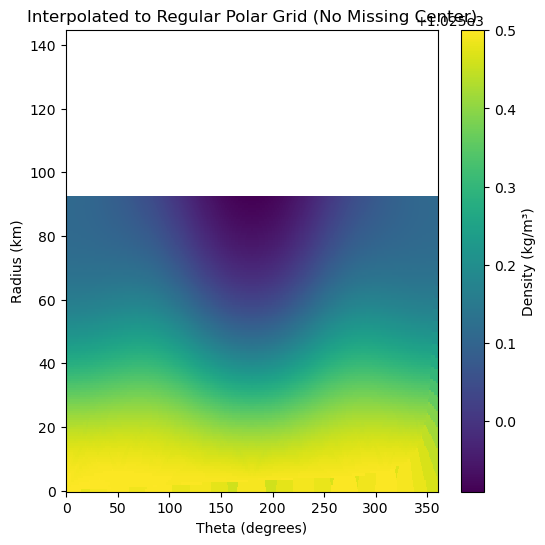

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ---------------------------------------------------------
# 1. Create synthetic (lon, lat) grid and data
# ---------------------------------------------------------
lon_center, lat_center = -120.0, 34.0
lon = np.linspace(lon_center - 1, lon_center + 1, 51)
lat = np.linspace(lat_center - 1, lat_center + 1, 51)
lon, lat = np.meshgrid(lon, lat)

data = 1025 + 0.5 * np.exp(-((lon - lon_center)**2 + (lat - lat_center)**2) / 0.5**2)
data += 0.1 * (lon - lon_center)

# ---------------------------------------------------------
# 2. Convert to polar coordinates (fixed angular definition)
# ---------------------------------------------------------
def lonlat_to_polar_planar(lon, lat, lon0=None, lat0=None):
    R_earth = 6371.0  # km
    if lon0 is None:
        lon0 = np.mean(lon)
    if lat0 is None:
        lat0 = np.mean(lat)

    deg2km_lat = (np.pi / 180.0) * R_earth
    deg2km_lon = deg2km_lat * np.cos(np.deg2rad(lat0))

    dx = (lon - lon0) * deg2km_lon   # east-west
    dy = (lat - lat0) * deg2km_lat   # north-south

    r = np.sqrt(dx**2 + dy**2)
    theta = (np.degrees(np.arctan2(dy, dx)) + 360.0) % 360.0  # 0° east, CCW
    return r, theta

r, theta = lonlat_to_polar_planar(lon, lat)

# ---------------------------------------------------------
# 3. Interpolate onto a regular polar grid
# ---------------------------------------------------------
# Define regular polar grid
r_bins = np.linspace(0, np.nanmax(r), 200)       # 200 radial bins
theta_bins = np.linspace(0, 360, 360)            # 1° angular bins

R, THETA = np.meshgrid(r_bins, theta_bins)
points = np.column_stack((r.ravel(), theta.ravel()))
values = data.ravel()

# --- Estimate inner radius threshold automatically ---
# (approximately one grid spacing in km)
dr_est = np.nanmin(np.diff(np.sort(np.unique(r[:, r.shape[1]//2]))))
r_thresh = np.maximum(0.5 * dr_est, 1.0)  # km
center_val = np.nanmean(values[r.ravel() < r_thresh])

# --- Add synthetic center point ---
points = np.vstack((points, [0.0, 0.0]))
values = np.append(values, center_val)

# --- First pass: linear interpolation ---
data_polar = griddata(points, values, (R, THETA), method='linear')

# --- Second pass: fill NaNs near the origin with nearest-neighbor interpolation ---
missing = np.isnan(data_polar)
if np.any(missing):
    data_polar[missing] = griddata(points, values, (R[missing], THETA[missing]), method='nearest')

# ---------------------------------------------------------
# 4. Mask outside the inscribed circle (optional)
# ---------------------------------------------------------
r_edges = np.concatenate([r[0, :], r[-1, :], r[:, 0], r[:, -1]])
r_max_valid = np.nanmin(r_edges)
data_polar[R > r_max_valid] = np.nan

# ---------------------------------------------------------
# 5. Plot clean polar field
# ---------------------------------------------------------
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
p = ax.pcolormesh(np.deg2rad(THETA), R, data_polar, cmap='viridis', shading='auto')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Interpolated to Regular Polar Grid (No Missing Center)')
ax.grid(False)
plt.show()

# ---------------------------------------------------------
# 6. Cartesian-style view of polar grid
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
p = ax.pcolormesh(THETA, R, data_polar, cmap='viridis', shading='auto')
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_xlabel('Theta (degrees)')
ax.set_ylabel('Radius (km)')
ax.set_title('Interpolated to Regular Polar Grid (No Missing Center)')
ax.grid(False)
plt.show()
